#### Import

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from tqdm import tqdm
from functions_utils import *
from functions_data import *
from functions_optimize import *
from functions_eval import *

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
S, R, P_RT, K, K0, M1, M2 = load_parameters(I, T, generation_data)
P_DA, P_PN = load_price_data()

✅ 총 5개 파일을 불러왔습니다: 1201.csv, 137.csv, 401.csv, 524.csv, 89.csv
📊 데이터 Shape: I=5, T=24, S=20
✅ 시뮬레이션 초기화 완료: S=20, Randomness='high', M1=757.00, M2=2111.00


#### Preliminaries

In [2]:
print("[Individual Participation Model optimization]")
x_ind, yp_ind, ym_ind, z_ind, zc_ind, zd_ind, obj_ind = optimize_individually_forall(R, K, K0, P_DA, P_RT, P_PN, I, T, S, M1)
print("-"*100)

print("[Holistic Aggregation Model optimization]")
x_hol, a_hol, yp_hol, ym_hol, z_hol, zc_hol, zd_hol, ep_hol, bp_hol, em_hol, bm_hol, d_hol, dp_hol, dm_hol, obj_hol = optimize_hol(R, K, K0, P_DA, P_RT, P_PN, I, T, S, M1, M2)
print("-"*100)

print("[Extracting target_i from Holistic Aggregation Model]")
x_extracted, ep_extracted, em_extracted, yp_extracted, ym_extracted, d_extracted, dp_extracted, dm_extracted, i_map_extracted = extracted_target(I, T, S, x_hol, ep_hol, em_hol, yp_hol, ym_hol, d_hol, dp_hol, dm_hol)
print("-"*100)

print("[Holistic Aggregation Model optimization without target_i]")
x_without, ep_without, em_without, yp_without, ym_without, d_without, dp_without, dm_without, i_map_without = optimize_without_loop(R, K, K0, P_DA, P_RT, P_PN, I, T, S)
print("-"*100)

[Individual Participation Model optimization]


Optimizing individually for each target_i:   0%|          | 0/5 [00:00<?, ?it/s]

Set parameter Username
Set parameter LicenseID to value 2681721
Academic license - for non-commercial use only - expires 2026-06-24
Set parameter MIPGap to value 1e-07


Optimizing individually for each target_i:  20%|██        | 1/5 [00:00<00:00,  6.49it/s]

Optimal solution found for target_i=0! Objective value: 217787.05981901792
Set parameter MIPGap to value 1e-07


...

Set parameter MIPGap to value 1e-07


Solving settlement model for each target DER:  80%|████████  | 4/5 [00:32<00:07,  7.52s/it]

Set parameter MIPGap to value 1e-07


Solving settlement model for each target DER: 100%|██████████| 5/5 [00:43<00:00,  8.67s/it]

----------------------------------------------------------------------------------------------------


#### Price Functions

In [44]:
# 개별 참여자별 demand curve와 supply curve 생성
individual_demand_curves = np.zeros((I, T, S, 2))  # [i, t, s, (slope, intercept)]
individual_supply_curves = np.zeros((I, T, S, 2))  # [i, t, s, (slope, intercept)]

for target_i in range(I):
    for t in range(T):
        for s in range(S):
            # Demand curve
            slope_d = P_RT[t, s] - P_PN[t]
            x0_d = dp_hol[target_i, t, s]
            y0_d = P_PN[t]
            intercept_d = y0_d - slope_d * x0_d
            individual_demand_curves[target_i, t, s, 0] = slope_d
            individual_demand_curves[target_i, t, s, 1] = intercept_d
            
            # Supply curve
            slope_s = P_PN[t] - P_RT[t, s]
            x0_s = dm_hol[target_i, t, s]
            y0_s = P_RT[t, s]
            intercept_s = y0_s - slope_s * x0_s
            individual_supply_curves[target_i, t, s, 0] = slope_s
            individual_supply_curves[target_i, t, s, 1] = intercept_s

# Aggregated demand curve 생성 (수평 합산)
aggregated_demand_curves = np.zeros((T, S, 2))  # [t, s, (slope, intercept)]

for t in range(T):
    for s in range(S):
        # 여러 가격점에서 수량을 합산하여 aggregated demand curve 생성
        price_points = np.linspace(0, 200, 100)  # 가격 범위
        total_demand_quantities = []
        
        for price in price_points:
            total_q = 0
            for i in range(I):
                slope = individual_demand_curves[i, t, s, 0]
                intercept = individual_demand_curves[i, t, s, 1]
                # 각 참여자의 demand curve에서 해당 가격에서의 수량 계산
                q = (price - intercept) / slope if slope != 0 else 0
                q = max(0, q)  # 음수 수량 방지
                total_q += q
            total_demand_quantities.append(total_q)
        
        # Aggregated demand curve를 선형으로 근사
        X = np.array(price_points).reshape(-1, 1)
        y = np.array(total_demand_quantities)
        model = LinearRegression().fit(X, y)
        
        aggregated_demand_curves[t, s, 0] = model.coef_[0]  # 기울기
        aggregated_demand_curves[t, s, 1] = model.intercept_  # 절편

# Aggregated supply curve 생성 (수평 합산)
aggregated_supply_curves = np.zeros((T, S, 2))  # [t, s, (slope, intercept)]

for t in range(T):
    for s in range(S):
        # 여러 가격점에서 수량을 합산하여 aggregated supply curve 생성
        price_points = np.linspace(0, 200, 100)  # 가격 범위
        total_supply_quantities = []
        
        for price in price_points:
            total_q = 0
            for i in range(I):
                slope = individual_supply_curves[i, t, s, 0]
                intercept = individual_supply_curves[i, t, s, 1]
                # 각 참여자의 supply curve에서 해당 가격에서의 수량 계산
                q = (price - intercept) / slope if slope != 0 else 0
                q = max(0, q)  # 음수 수량 방지
                total_q += q
            total_supply_quantities.append(total_q)
        
        # Aggregated supply curve를 선형으로 근사
        X = np.array(price_points).reshape(-1, 1)
        y = np.array(total_supply_quantities)
        model = LinearRegression().fit(X, y)
        
        aggregated_supply_curves[t, s, 0] = model.coef_[0]  # 기울기
        aggregated_supply_curves[t, s, 1] = model.intercept_  # 절편


t_example, s_example = 15, 0
print(f"\n시간대 {t_example}, 시나리오 {s_example}에서의 Aggregated Curves:")
print(f"Demand Curve: p = {aggregated_demand_curves[t_example, s_example, 1]:.3f} + {aggregated_demand_curves[t_example, s_example, 0]:.3f} * q")
print(f"Supply Curve: p = {aggregated_supply_curves[t_example, s_example, 1]:.3f} + {aggregated_supply_curves[t_example, s_example, 0]:.3f} * q")


시간대 15, 시나리오 0에서의 Aggregated Curves:
Demand Curve: p = 0.000 + 0.000 * q
Supply Curve: p = 26.577 + -0.084 * q


In [ ]:
def compute_rho_plus(yp_without, ym_without, dp_without, dm_without, i_map_without, P_RT, P_PN, T, S, I):
    rdc_coefficients_all = np.full((I, T, S, 2), np.nan)
    rho_plus_func_all = np.full((I, T, S, 2), np.nan)   # RDC
    
    total_demand_without = np.zeros((I, T, S))
    total_supply_without = np.zeros((I, T, S))

    for target_i in range(I):
        yp_vals = yp_without[target_i]
        ym_vals = ym_without[target_i]
        dp_vals = dp_without[target_i]
        dm_vals = dm_without[target_i]
        i_map = i_map_without[target_i]

        for t in range(T):
            for s in range(S):
                total_supply = sum(yp_vals[i_map[i], t, s] for i in i_map)
                total_demand = sum(ym_vals[i_map[i], t, s] for i in i_map)
                
                total_supply_without[target_i, t, s] = total_supply
                total_demand_without[target_i, t, s] = total_demand

                realized_supply = realized_demand = 0

                for i in i_map:
                    realized_supply += dp_vals[i_map[i], t, s]
                    realized_demand += dm_vals[i_map[i], t, s]

                BIG_M_NEG = -1e10

                if realized_demand <= 1e-4 or realized_supply <= 1e-4:
                    rho_plus_func_all[target_i, t, s, :] = [BIG_M_NEG, 0.0]
                    continue

                a_d = 
                b_d = P_RT[t, s] - P_PN[t]
                a_s = 
                b_s = P_PN[t] - P_RT[t, s]

                denom = b_d + b_s
                if abs(denom) < 1e-6: continue

                # === RDC: q0 → 공급 증가 ===
                q0_list_rdc = np.linspace(-1, 1.1 * total_supply, 10)
                prices_rdc = []
                for q0 in q0_list_rdc:
                    q_cleared = (a_d - a_s + b_s * q0) / denom
                    p_cleared = a_d - b_d * q_cleared
                    prices_rdc.append(p_cleared)
                q_rdc = np.array(q0_list_rdc).reshape(-1, 1)
                p_rdc = np.array(prices_rdc)

                # 선형 회귀 근사 (1차)
                X_poly_rdc = PolynomialFeatures(degree=1).fit_transform(q_rdc)
                model_rdc = LinearRegression().fit(X_poly_rdc, p_rdc)
                a_rdc, b_rdc = model_rdc.intercept_, model_rdc.coef_[1]

                rho_plus_func_all[target_i, t, s, :] = [a_rdc, b_rdc]
                rdc_coefficients_all[target_i, t, s, :] = [a_rdc, b_rdc]

    return rdc_coefficients_all, rho_plus_func_all, total_demand_without, total_supply_without

In [4]:
def compute_rho_minus(yp_without, ym_without, dp_without, dm_without, i_map_without, P_RT, P_PN, T, S, I):
    rsc_coefficients_all = np.full((I, T, S, 2), np.nan)
    rho_minus_func_all = np.full((I, T, S, 2), np.nan)  # RSC
    
    total_demand_without = np.zeros((I, T, S))
    total_supply_without = np.zeros((I, T, S))

    for target_i in range(I):
        yp_vals = yp_without[target_i]
        ym_vals = ym_without[target_i]
        dp_vals = dp_without[target_i]
        dm_vals = dm_without[target_i]
        i_map = i_map_without[target_i]

        for t in range(T):
            for s in range(S):
                total_supply = sum(yp_vals[i_map[i], t, s] for i in i_map)
                total_demand = sum(ym_vals[i_map[i], t, s] for i in i_map)
                
                total_supply_without[target_i, t, s] = total_supply
                total_demand_without[target_i, t, s] = total_demand

                given_profit = received_profit = realized_supply = realized_demand = 0

                for i in i_map:
                    given_profit += dp_vals[i_map[i], t, s] * P_PN[t]
                    received_profit += dm_vals[i_map[i], t, s] * P_RT[t, s] 
                    realized_supply += dp_vals[i_map[i], t, s]
                    realized_demand += dm_vals[i_map[i], t, s]

                BIG_M_POS = 1e10

                if realized_demand <= 1e-4 or realized_supply <= 1e-4:
                    rho_minus_func_all[target_i, t, s, :] = [BIG_M_POS, 0.0]
                    continue

                a_d = P_PN[t]
                b_d = 2 * (a_d * realized_demand - received_profit) / (realized_demand ** 2)
                a_s = P_RT[t, s]
                b_s = 2 * (given_profit - a_s * realized_supply) / (realized_supply ** 2)

                denom = b_d + b_s
                if abs(denom) < 1e-6: continue

                # === RSC: q0 → 수요 증가 ===
                q0_list_rsc = np.linspace(-1, 1.1 * total_demand, 10)
                prices_rsc = []
                for q0 in q0_list_rsc:
                    q_cleared = (a_d + b_d * q0 - a_s) / denom
                    p_cleared = a_s + b_s * q_cleared
                    prices_rsc.append(p_cleared)
                q_rsc = np.array(q0_list_rsc).reshape(-1, 1)
                p_rsc = np.array(prices_rsc)

                # 선형 회귀 근사 (1차)
                X_poly_rsc = PolynomialFeatures(degree=1).fit_transform(q_rsc)
                model_rsc = LinearRegression().fit(X_poly_rsc, p_rsc)

                a_rsc, b_rsc = model_rsc.intercept_, model_rsc.coef_[1]

                rho_minus_func_all[target_i, t, s, :] = [a_rsc, b_rsc]
                rsc_coefficients_all[target_i, t, s, :] = [a_rsc, b_rsc]

    return rsc_coefficients_all, rho_minus_func_all, total_demand_without, total_supply_without

In [ ]:
def compute_price_functions(yp_extracted, ym_extracted, dp_extracted, dm_extracted, i_map_extracted, P_RT, P_PN, T, S, I):
    rdc_coefficients_all, rho_plus_func_all, total_demand_without, total_supply_without = compute_rho_plus(yp_extracted, ym_extracted, dp_extracted, dm_extracted, i_map_extracted, P_RT, P_PN, T, S, I)
    rsc_coefficients_all, rho_minus_func_all, _, _ = compute_rho_minus(yp_extracted, ym_extracted, dp_extracted, dm_extracted, i_map_extracted, P_RT, P_PN, T, S, I)
    
    return rdc_coefficients_all, rsc_coefficients_all, rho_plus_func_all, rho_minus_func_all, total_demand_without, total_supply_without

rdc, rsc, rho_plus, rho_minus, total_demand_without, total_supply_without = compute_price_functions(yp_extracted, ym_extracted, dp_extracted, dm_extracted, i_map_extracted, P_RT, P_PN, T, S, I)


In [ ]:
# def compute_price_functions(yp_without, ym_without, dp_without, dm_without, i_map_without, P_RT, P_PN, T, S, I):
#     rdc_coefficients_all, rho_plus_func_all, total_demand_without, total_supply_without = compute_rho_plus(yp_without, ym_without, dp_without, dm_without, i_map_without, P_RT, P_PN, T, S, I)
#     rsc_coefficients_all, rho_minus_func_all, _, _ = compute_rho_minus(yp_without, ym_without, dp_without, dm_without, i_map_without, P_RT, P_PN, T, S, I)
    
#     return rdc_coefficients_all, rsc_coefficients_all, rho_plus_func_all, rho_minus_func_all, total_demand_without, total_supply_without

# rdc, rsc, rho_plus, rho_minus, total_demand_without, total_supply_without = compute_price_functions(yp_without, ym_without, dp_without, dm_without, i_map_without, P_RT, P_PN, T, S, I)

In [6]:
target_i, t, s = 1, 10, 0
ap, bp = rho_plus[target_i, t, s, :]
am, bm = rho_minus[target_i, t, s, :]
print(f"ρ⁺(d) = {ap:.2f} + {bp:.2f}·d")
print(f"ρ⁻(d) = {am:.2f} + {bm:.2f}·d")

ρ⁺(d) = -10000000000.00 + 0.00·d
ρ⁻(d) = 10000000000.00 + 0.00·d


In [ ]:
for target_i in range(I):
        yp_vals = yp_extracted[target_i]
        ym_vals = ym_extracted[target_i]
        dp_vals = dp_extracted[target_i]
        dm_vals = dm_extracted[target_i]
        i_map = i_map_extracted[target_i]

        for t in range(T):
            for s in range(S):
                total_supply = sum(yp_vals[i_map[i], t, s] for i in i_map)
                total_demand = sum(ym_vals[i_map[i], t, s] for i in i_map)
                
                total_supply_without[target_i, t, s] = total_supply
                total_demand_without[target_i, t, s] = total_demand

RP, RM, BP, BM = transform_step(rho_plus, rho_minus, total_demand_without, total_supply_without, step_width_multiplier=1)

In [8]:
print(yp_without[target_i][:, t, s])
print(BP[target_i, t, s])
print(RP[target_i, t, s])

print(ym_without[target_i][:, t, s])
print(BM[target_i, t, s])
print(RM[target_i, t, s])

[0. 0. 5. 0.]
1
[[ 0.e+00 -1.e+10]]
[0. 0. 0. 0.]
5
[[0.0e+00 1.0e+10]
 [5.0e-01 1.0e+10]
 [1.5e+00 1.0e+10]
 [2.5e+00 1.0e+10]
 [3.5e+00 1.0e+10]
 [4.5e+00 1.0e+10]]


#### Stepwise Model

In [9]:
x_part, yp_part, ym_part, z_part, zc_part, zd_part, dp_part, dm_part, up_part, um_part, wp_part, wm_part, obj_part, RP_CLEARED, RM_CLEARED = stepwise_optimize_forall(I, T, S, R, K, K0, P_DA, P_RT, P_PN, RP, RM, BP, BM, total_demand_without, total_supply_without, M1)

Optimizing Stepwise for each target_i: 100%|██████████| 5/5 [00:39<00:00,  7.90s/it]


In [10]:
BEST_CASE_PROFIT = calculate_total_profit_best_case(x_part, yp_part, ym_part, dp_part, dm_part, dp_extracted, dm_extracted, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
WORST_CASE_PROFIT = calculate_total_profit_worst_case(x_part, yp_part, ym_part, dp_part, dm_part, dp_extracted, dm_extracted, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
NO_VIRTUAL_PRICE_PROFIT = calculate_total_profit_no_virtual_price(x_part, yp_part, ym_part, dp_part, dm_part, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)

#### Evaluation

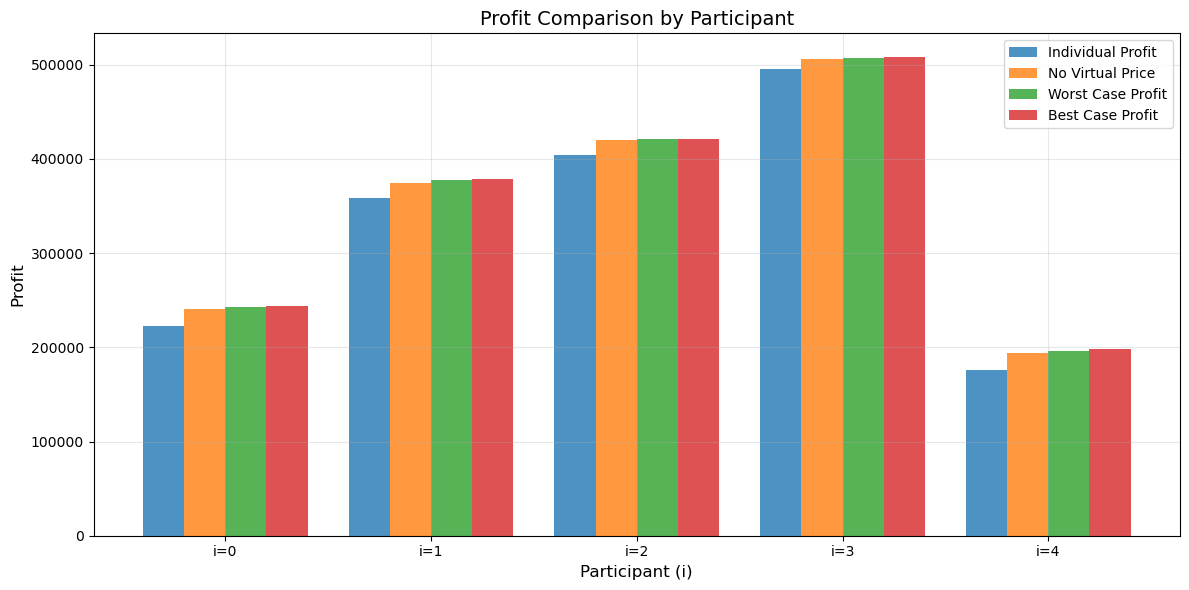

In [11]:
evaluate_and_visualize_profits(x_ind, yp_ind, ym_ind, P_DA, P_RT, P_PN, NO_VIRTUAL_PRICE_PROFIT, WORST_CASE_PROFIT, BEST_CASE_PROFIT, T, S, I)


In [12]:
# compare_individual_solutions(x_part, yp_part, ym_part, dp_part, dm_part, x_ind, yp_ind, ym_ind, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
print_summary_only(x_part, yp_part, ym_part, dp_part, dm_part, x_ind, yp_ind, ym_ind, T, S, I)


타겟 참여자 0번의 합계:
-------------------------------------------------------------------------------------------------------------------------------------------------
 합계 |            107.50   385.00 ||                    84.42            901.53   708.95 ||                     9.65              0.00    10.15

타겟 참여자 1번의 합계:
-------------------------------------------------------------------------------------------------------------------------------------------------
 합계 |            189.00   628.00 ||                   105.58           1541.43  1209.55 ||                    18.55              0.00    20.10

타겟 참여자 2번의 합계:
-------------------------------------------------------------------------------------------------------------------------------------------------
 합계 |            424.50   782.00 ||                    66.35           1654.65  1365.55 ||                    14.07              0.38    16.50

타겟 참여자 3번의 합계:
---------------------------------------------------------------------

In [13]:
calculate_aggregated_profit_evaluation(x_ind, yp_ind, ym_ind, NO_VIRTUAL_PRICE_PROFIT, WORST_CASE_PROFIT, BEST_CASE_PROFIT, a_hol, bp_hol, bm_hol, P_DA, P_RT, P_PN, T, S, I)

In [14]:
compare_time_scenario_averages(a_hol, bp_hol, bm_hol, dp_hol, dm_hol, x_part, yp_part, ym_part, dp_part, dm_part, T, S, I)

시간별 시나리오 평균 비교
--------------------------------------------------------------------------------------------------------------------------------------------
 t |    a_hol   x_part_sum |   bp_hol_avg  yp_part_sum |   bm_hol_avg  ym_part_sum |   dp_hol_sum  dp_part_sum |   dm_hol_sum  dm_part_sum
--------------------------------------------------------------------------------------------------------------------------------------------
 0 |     0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 1 |     0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 2 |     0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 3 |     0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 4 |    